In [55]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import f, t

In [2]:
df = pd.DataFrame({
    'Estudiante': range(1, 11),
    'Horas': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nota': [3.2, 4.5, 5.0, 6.8, 7.0, 8.5, 9.0, 9.2, 9.8, 10.0]
})

In [3]:
df

,Estudiante,Horas,Nota
0,1,1,3.2
1,2,2,4.5
2,3,3,5.0
3,4,4,6.8
4,5,5,7.0
5,6,6,8.5
6,7,7,9.0
7,8,8,9.2
8,9,9,9.8
9,10,10,10.0


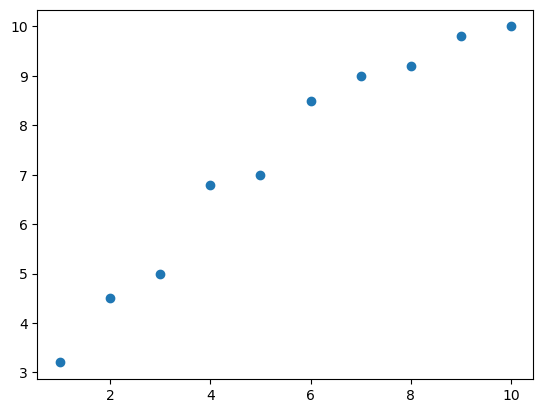

In [4]:
plt.scatter(df['Horas'], df['Nota'])
plt.show()

In [5]:
x = df['Horas']
y = df['Nota']
x_mean = sum(x) / len(x)
y_mean= y.mean()
x_mean, y_mean


(5.5, 7.3)

In [6]:
b1 = sum((x - x_mean) * (y - y_mean)) / sum(((x - x_mean)**2))
b0 = y_mean - (b1 * x_mean)
b1, b0

(0.7721212121212122, 3.053333333333333)

In [7]:
y_pred = b0 + b1 * x

In [8]:
sst = sum((y - y_mean)**2)
ssr = sum((y_pred - y_mean)**2)
sse = sum((y - y_pred)**2)
sst, ssr, sse

(51.76, 49.18412121212123, 2.5758787878787905)

In [9]:
n = len(x)

In [10]:
df_total = n - 1
df_regresion = 1 
df_error = n - df_regresion - 1

In [34]:
# Cuadrados medios
msr = ssr / df_regresion
mse = sse / df_error
F = msr / mse

In [35]:
print("Tabla Anova")
print(f"{'Fuente':<12} {'SS':>12} {'df':>8} {'MS':>12} {'F':>12}")
print('')
print(f"{'Regresión |':<12} {ssr:>12.4f} {df_regresion:>8} {msr:>12.4f} {F:>12.4f}")
print(f"{'Error |':<12} {sse:>12.4f} {df_error:>8} {mse:>12.4f}")
print(f"{'Total |':<12} {sst:>12.4f} {df_total:>8}")

Tabla Anova
Fuente                 SS       df           MS            F

Regresión |       49.1841        1      49.1841     152.7529
Error |            2.5759        8       0.3220
Total |           51.7600        9


In [41]:
F_critico = f.ppf(0.95, df_regresion, df_error)
F_critico

5.317655071578714

Si \
F > F_crítico → Rechazar H₀ \
F < F_crítico → No rechazar H₀ \
Por lo tanto se rechaza H₀, lo que representa que el modelo es significativo

In [46]:
sxx = sum((x - x_mean)**2)

In [51]:
SE_b1 = np.sqrt(mse / sxx)
t_prueba = b1 / SE_b1    
t_prueba

12.359324647633942

In [57]:
t_critico = t.ppf(0.975, df_error)
t_critico

2.306004135204166

Si \
|t| > t_crítico → Rechazar H₀ \
|t| < t_crítico → No rechazar H₀ \
Por lo que, rechazamos H₀, lo que signfica que Beta1 es significativa

In [60]:
F == t_prueba**2

True

Relacion verdadera entre prueba F y t

In [62]:
SE_b0 = np.sqrt(mse * (1/n + x_mean**2 / sxx))
t_prueba_0 = b0 / SE_b0
t_prueba_0

7.876859710225449

In [64]:
alpha = 0.05
t_alpha_2 = t.ppf(1 - alpha/2, df_error)

In [67]:
IC_b0_inf = b0 - t_alpha_2 * SE_b0
IC_b0_sup = b0 + t_alpha_2 * SE_b0
print('Valores para b0')
[IC_b0_inf, IC_b0_sup]

Valores para b0


[2.1594492790466964, 3.947217387619969]

In [68]:
IC_b1_inf = b1 - t_alpha_2 * SE_b1
IC_b1_sup = b1 + t_alpha_2 * SE_b1
print('Valores para b1')
[IC_b1_inf, IC_b1_sup]

Valores para b1


[0.6280587524971559, 0.9161836717452685]

El intervalo no contiene 0 → β₁, por lo que sí es significativo

In [81]:
IC_inf = []
IC_sup = []
IP_inf = []
IP_sup = []
SE_means = []
SE_preds = []

In [82]:
for i, x0 in enumerate(x):
    
    SE_mean = np.sqrt(mse * (1/n + (x0 - x_mean)**2 / sxx))
    SE_pred = np.sqrt(mse * (1 + 1/n + (x0 - x_mean)**2 / sxx))
    
    SE_means.append(SE_mean)
    SE_preds.append(SE_pred)
    
    IC_inf.append(y_pred.iloc[i] - t_alpha_2 * SE_mean)
    IC_sup.append(y_pred.iloc[i] + t_alpha_2 * SE_mean)
    
    IP_inf.append(y_pred.iloc[i] - t_alpha_2 * SE_pred)
    IP_sup.append(y_pred.iloc[i] + t_alpha_2 * SE_pred)

tabla_final = pd.DataFrame({
    'Horas': x,
    'Nota': y,
    'ŷ': y_pred,
    'SE_mean': [f'{se:.4f}' for se in SE_means],
    'IC 95% Media': [f'[{IC_inf[i]:.3f}, {IC_sup[i]:.3f}]' for i in range(len(x))],
    'SE_pred': [f'{se:.4f}' for se in SE_preds],
    'IP 95%': [f'[{IP_inf[i]:.3f}, {IP_sup[i]:.3f}]' for i in range(len(x))]
})

print(tabla_final.to_string(index=False))

 Horas  Nota         ŷ SE_mean     IC 95% Media SE_pred          IP 95%
     1   3.2  3.825455  0.3335   [3.056, 4.595]  0.6582  [2.308, 5.343]
     2   4.5  4.597576  0.2829   [3.945, 5.250]  0.6340  [3.136, 6.060]
     3   5.0  5.369697  0.2379   [4.821, 5.918]  0.6153  [3.951, 6.789]
     4   6.8  6.141818  0.2024   [5.675, 6.609]  0.6025  [4.753, 7.531]
     5   7.0  6.913939  0.1821   [6.494, 7.334]  0.5960  [5.540, 8.288]
     6   8.5  7.686061  0.1821   [7.266, 8.106]  0.5960  [6.312, 9.060]
     7   9.0  8.458182  0.2024   [7.991, 8.925]  0.6025  [7.069, 9.847]
     8   9.2  9.230303  0.2379   [8.682, 9.779]  0.6153 [7.811, 10.649]
     9   9.8 10.002424  0.2829  [9.350, 10.655]  0.6340 [8.540, 11.464]
    10  10.0 10.774545  0.3335 [10.005, 11.544]  0.6582 [9.257, 12.292]
